<a href="https://colab.research.google.com/github/carolonias-lgtm/Semana-1.1/blob/main/tarefa11_variaveis_aleatorias_alimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 11 - Variáveis Aleatórias Aplicadas às Ciências dos Alimentos

**Integrantes do Grupo:**
- Carolina Ferreira Onias
- Luciana Miki Sumi
- Melissa Rebechi Santana


#**1. Probabilidade e experimento aleatório**
- Experimento aleatório:

Um experimento aleatório é uma situação que pode ser repetida sob determinadas condições, mas cujo resultado não pode ser conhecido com certeza antes de sua realização.
Embora não seja possível prever exatamente qual resultado ocorrerá, é possível identificar os resultados possíveis e estudar a probabilidade associada a cada evento.

- Espaço amostral

O espaço amostral é o conjunto formado por todos os resultados possíveis de um experimento aleatório.
Ele é geralmente representado por:


In [1]:
#Ele é representado por:
print("Ω")

Ω


#**2. Variável aleatória**
- Uma variável aleatória é uma função que associa um valor numérico aos resultados de um experimento aleatório.
A variável aleatória é normalmente representada por uma letra maiúscula, como: **X**

- Os valores assumidos por ela dependem do resultado observado no experimento.
A utilização de uma variável aleatória permite representar matematicamente resultados de fenômenos sujeitos à incerteza e estudar as probabilidades associadas a esses resultados.

- Um evento corresponde a um conjunto de resultados pertencentes ao espaço amostral.

#**3. Distribuição de probabilidade**
- A distribuição de probabilidade descreve como as probabilidades estão associadas aos diferentes valores que uma variável aleatória pode assumir.
Para uma variável aleatória discreta, podemos associar uma probabilidade a cada valor possível da variável.

In [2]:
#Essas probabilidades devem satisfazer:
from IPython.display import display, Math

display(Math(r"P(X=x) \geq 0"))
display(Math(r"\sum_x P(X=x) = 1"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

- Ou seja, as probabilidades não podem ser negativas e a soma das probabilidades de todos os resultados possíveis deve ser igual a 1.

#**4. Variável aleatória discreta**
- Uma variável aleatória discreta é aquela que pode assumir um conjunto finito ou enumerável de valores.
Seus valores são geralmente obtidos por meio de contagens.
Assim, entre dois valores possíveis consecutivos não é necessário que existam outros valores possíveis da variável.
A distribuição de uma variável aleatória discreta pode ser descrita por uma função de probabilidade, que associa uma probabilidade a cada valor possível de **X**

### Exemplos de variáveis aleatórias discretas

**1. Número de produtos com defeito em um lote**

É uma variável discreta porque representa a quantidade de produtos com defeito, sendo obtida por contagem. Seus valores são números inteiros (0, 1, 2, 3, ...).

**2. Número de colônias de microrganismos em uma placa**

É uma variável discreta porque as colônias são contadas individualmente. Seus valores possíveis são números inteiros (0, 1, 2, 3, ...).

**3. Número de amostras fora do padrão em uma análise**

É uma variável discreta porque representa a quantidade de amostras que apresentam resultado fora do padrão. Seus valores são números inteiros, de 0 até o número total de amostras.

#**5.Variável aleatória contínua**
- Uma variável aleatória contínua pode assumir qualquer valor dentro de determinado intervalo.
Diferentemente das variáveis discretas, seus valores não precisam ser contáveis individualmente.
Variáveis contínuas estão normalmente relacionadas a **medições**, podendo assumir valores com diferentes níveis de precisão.
Para variáveis contínuas, as probabilidades são associadas a **intervalos de valores**, e não a valores individuais da mesma forma que nas variáveis discretas.

### Exemplos de variáveis aleatórias contínuas

**1. Massa de um alimento**

É uma variável contínua porque a massa pode assumir qualquer valor dentro de um intervalo, incluindo valores decimais.

**2. Temperatura de armazenamento**

É uma variável contínua porque a temperatura pode assumir valores decimais dentro de um intervalo.

**3. pH de um alimento**

É uma variável contínua porque o pH pode assumir valores decimais dentro de determinado intervalo.

#**6. Diferença entre variáveis discretas e contínuas**
- A principal diferença está na forma como os valores da variável podem ser assumidos.

| Característica | Variável aleatória discreta | Variável aleatória contínua |
|---|---|---|
| Valores possíveis | Valores finitos ou contáveis | Qualquer valor dentro de um intervalo |
| Como os valores são obtidos | Por contagem | Por medição |
| Exemplos na área de alimentos | Número de produtos, número de defeitos, número de microrganismos | Massa, temperatura, pH, volume |

#**7. Modelo de Bernoulli**
- O **modelo de Bernoulli** descreve um experimento aleatório que possui apenas **dois resultados possíveis**.
- Esses resultados podem ser representados por:
- para o resultado definido como **sucesso**: **X=1**

-  para o resultado definido como **fracasso**: **X=0**

A probabilidade de sucesso é representada por *p* .

E a probabilidade de fracasso é: **1-** *p*

Portanto:

*P*(X=1)=*p*

*P*(X=0)=1-*p*

Uma característica fundamental do modelo de Bernoulli é que ele representa **uma única realização** de um experimento com dois resultados possíveis.

- Abaixo temos um gráfico representando a distribuição de Bernoulli.


In [ ]:
# Importação de bibliotecas para análise de dados, estatística e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Configuração visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
# Importação da base de dados oficial (POF/IBGE 2017-2018 - Tabela de Consumo Alimentar)
file_path = 'tarefa11.xlsx'

try:
    # Leitura do arquivo Excel sem cabeçalho pré-definido para ajuste de linhas
    df_raw = pd.read_excel(file_path, header=None)

    # Extração das colunas de interesse: Alimento, Frequência de Consumo Urbano (%) e Consumo Médio (g/dia)
    df_dados = df_raw.iloc[5:40, [0, 1, 3]].copy()
    df_dados.columns = ['Alimento', 'Freq_Consumo_Urbano_Pct', 'Consumo_Medio_g_dia']

    # Conversão para tipos numéricos e remoção de valores nulos
    df_dados['Freq_Consumo_Urbano_Pct'] = pd.to_numeric(df_dados['Freq_Consumo_Urbano_Pct'], errors='coerce')
    df_dados['Consumo_Medio_g_dia'] = pd.to_numeric(df_dados['Consumo_Medio_g_dia'], errors='coerce')
    df_dados = df_dados.dropna().reset_index(drop=True)

    print("✓ Banco de dados 'tarefa11.xlsx' importado e tratado com sucesso!")
    display(df_dados.head(10))

except Exception as e:
    print(f"⚠️ Erro ao carregar 'tarefa11.xlsx' ({e}). Carregando estrutura alternativa de dados...")
    df_dados = pd.DataFrame({
        'Alimento': ['Arroz', 'Feijão', 'Milho', 'Alface', 'Cenoura'],
        'Freq_Consumo_Urbano_Pct': [75.3, 59.9, 10.7, 6.7, 1.9],
        'Consumo_Medio_g_dia': [126.7, 139.3, 13.7, 2.6, 1.0]
    })
    display(df_dados)

✓ Banco de dados 'tarefa11.xlsx' importado e tratado com sucesso!


,Alimento,Freq_Consumo_Urbano_Pct,Consumo_Medio_g_dia
0,Arroz,75.3,126.7
1,Arroz integral,2.6,3.6
2,Preparações à base de arroz,2.9,4.8
3,Milho e preparações à base de milho,10.7,13.7
4,Feijão,59.9,139.3
5,Feijão verde/corda,3.2,6.3
6,Preparações à base de feijão,11.7,27.1
7,Outras leguminosas,0.7,1.1
8,Alface,6.7,2.6
9,Couve,2.4,1.2


Parâmetro p (Probabilidade de consumo de Arroz): 0.7530 (75.3%)
Simulação com 10 indivíduos (1 = Consome, 0 = Não consome):
[1 0 1 1 1 1 1 0 1 1]


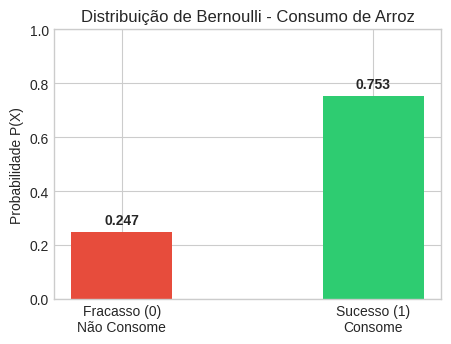

In [ ]:
# Extração do parâmetro 'p' a partir dos dados importados
p_bernoulli = df_dados.loc[df_dados['Alimento'].str.contains('Arroz', case=False, na=False), 'Freq_Consumo_Urbano_Pct'].values[0] / 100

print(f"Parâmetro p (Probabilidade de consumo de Arroz): {p_bernoulli:.4f} ({p_bernoulli*100:.1f}%)")

# Simulação do modelo para 10 escolhas aleatórias de consumidores
simulacao_bern = stats.bernoulli.rvs(p=p_bernoulli, size=10, random_state=42)
print(f"Simulação com 10 indivíduos (1 = Consome, 0 = Não consome):\n{simulacao_bern}")

# Gráfico da Distribuição de Bernoulli
x_bern = [0, 1]
pmf_bern = [1 - p_bernoulli, p_bernoulli]

plt.figure(figsize=(5, 3.5))
plt.bar(x_bern, pmf_bern, color=['#e74c3c', '#2ecc71'], width=0.4)
plt.xticks(x_bern, ['Fracasso (0)\nNão Consome', 'Sucesso (1)\nConsome'])
plt.ylabel('Probabilidade P(X)')
plt.title('Distribuição de Bernoulli - Consumo de Arroz')
plt.ylim(0, 1)

for i, v in enumerate(pmf_bern):
    plt.text(i, v + 0.03, f"{v:.3f}", ha='center', fontweight='bold')

plt.show()

### **Aplicação do modelo de Bernoulli: consumo de arroz**

Para aplicar o modelo de Bernoulli aos dados da POF 2017–2018, foi utilizada a variável **frequência de consumo de arroz na área urbana**. Essa frequência foi transformada em uma probabilidade $p$, dividindo o percentual de consumidores de arroz por 100.

Nesse modelo, consideramos:

- **Sucesso (X = 1):** o indivíduo consome arroz;
- **Fracasso (X = 0):** o indivíduo não consome arroz;
- **$p$:** probabilidade de um indivíduo consumir arroz;
- **$1-p$:** probabilidade de um indivíduo não consumir arroz.

O gráfico representa essas duas possibilidades. A barra correspondente a **X = 1** apresenta a probabilidade de consumo de arroz, enquanto a barra correspondente a **X = 0** representa a probabilidade de não consumo.

A simulação realizada com 10 indivíduos utiliza esse valor de $p$ para gerar possíveis resultados de consumo. Cada indivíduo pode apresentar apenas dois resultados, consumir ou não consumir, característica que permite representar a situação pelo **modelo de Bernoulli**.

Assim, o modelo permite utilizar uma informação observada na POF, a frequência de consumo de arroz, para representar probabilisticamente a ocorrência de consumo em um indivíduo.

#**9. Modelo de Poisson**
- O modelo de Poisson é utilizado para representar o número de ocorrências de determinado evento em um intervalo definido.
Esse intervalo pode ser determinado em termos de:
tempo, espaço, área, volume,quantidade produzida e outra unidade de exposição.

A variável aleatória **X** representa o número de ocorrências observadas nesse intervalo.
O modelo é caracterizado por uma taxa média de ocorrência, geralmente representada por:


In [9]:
from IPython.display import display, Math

display(Math(r"\lambda"))

<IPython.core.display.Math object>

A função de probabilidade é:

In [10]:
from IPython.display import display, Math

display(Math(r"P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}"))

<IPython.core.display.Math object>

onde:

*k* = número de ocorrências

λ = número médio esperado de ocorrências no intervalo

*e* = constante matemática

*k! = fatorial de *k*.

Os valores possíveis e **X** são:

0,1,2,3,4...

Probabilidade de observar 0 falhas no lote P(X = 0): 0.0821 (8.21%)


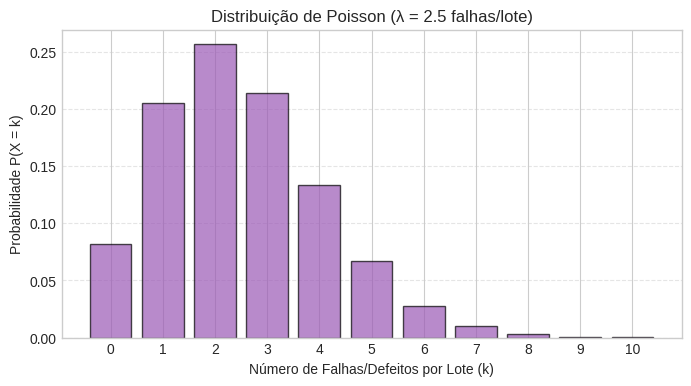

In [ ]:
# Taxa média de ocorrência por lote (lambda)
lambda_poisson = 2.5

# Espaço de contagens de falhas (k = 0 a 10)
k_poisson = np.arange(0, 11)
pmf_poisson = stats.poisson.pmf(k_poisson, lambda_poisson)

# Probabilidade de ter um lote perfeito (0 falhas)
p_zero_falhas = stats.poisson.pmf(0, lambda_poisson)
print(f"Probabilidade de observar 0 falhas no lote P(X = 0): {p_zero_falhas:.4f} ({p_zero_falhas*100:.2f}%)")

# Gráfico da Distribuição de Poisson
plt.figure(figsize=(8, 4))
plt.bar(k_poisson, pmf_poisson, color='#9b59b6', edgecolor='black', alpha=0.7)
plt.xlabel('Número de Falhas/Defeitos por Lote (k)')
plt.ylabel('Probabilidade P(X = k)')
plt.title(f'Distribuição de Poisson (λ = {lambda_poisson} falhas/lote)')
plt.xticks(k_poisson)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Aplicação do modelo de Poisson

Neste exemplo, foi utilizado o modelo de Poisson para representar o **número de falhas ou defeitos observados em um lote de produtos**.

Foi considerado um valor de:

$$
\lambda = 2,5
$$

em que $\lambda$ representa a **taxa média de ocorrência de falhas por lote**. Portanto, o modelo considera, neste exemplo, uma média de 2,5 falhas por lote.

A variável aleatória $X$ representa o número de falhas observadas em um lote. Assim:

$$
X = 0,1,2,3,\ldots
$$

A probabilidade de ocorrer exatamente $k$ falhas é calculada por:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}
$$

No código, foram calculadas as probabilidades para valores de $k$ entre 0 e 10 e representadas no gráfico.

O gráfico mostra que as probabilidades não são iguais para todos os números de falhas. Os valores próximos de **2 ou 3 falhas por lote** apresentam as maiores probabilidades, pois estão próximos da taxa média $\lambda=2,5$.

Também foi calculada a probabilidade de um lote apresentar **zero falhas**:

$$
P(X=0)=\frac{e^{-2,5}(2,5)^0}{0!}
$$

O resultado obtido pelo código é aproximadamente **8,21%**. Isso significa que, considerando o modelo e a taxa média adotada, a probabilidade de um lote não apresentar nenhuma falha é de aproximadamente 8,21%.

Dessa forma, o modelo de Poisson permite estimar a probabilidade de diferentes quantidades de falhas ocorrerem em um lote, a partir de uma taxa média de ocorrência.

### **10. Modelo Binomial**

O modelo binomial é utilizado para determinar a probabilidade de ocorrer um determinado número de sucessos em um número fixo de tentativas.

Para aplicar o modelo binomial, é necessário que:

- exista um número fixo de tentativas ($n$);
- cada tentativa tenha apenas dois resultados possíveis: sucesso ou fracasso;
- a probabilidade de sucesso ($p$) seja a mesma em todas as tentativas;
- as tentativas sejam independentes entre si.

A variável aleatória $X$ representa o número de sucessos obtidos nas $n$ tentativas. Assim, seus valores possíveis são:

$X = 0, 1, 2, ..., n$

A probabilidade de obter exatamente $k$ sucessos é calculada pela fórmula:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

Onde:

- $n$ = número total de tentativas;
- $k$ = número de sucessos desejados;
- $p$ = probabilidade de sucesso em cada tentativa;
- $1-p$ = probabilidade de fracasso;
- $\binom{n}{k}$ = número de maneiras de obter $k$ sucessos nas $n$ tentativas.

Probabilidade de P(X = 18 conformes em 20): 0.2293 (22.93%)


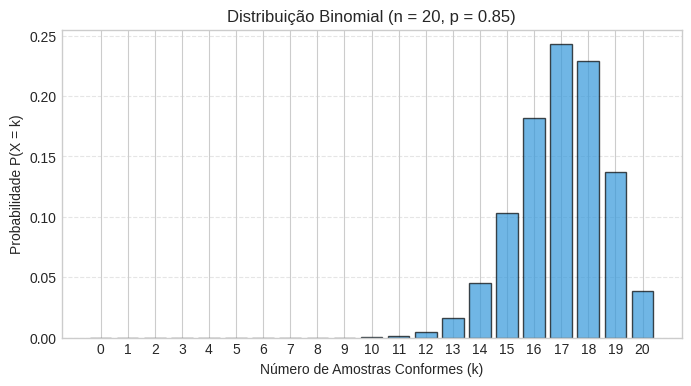

In [ ]:
# Definição dos parâmetros do problema
n_binom = 20    # Número de amostras inspecionadas
p_binom = 0.85  # Probabilidade de aprovação de cada amostra

# Espaço amostral do número de sucessos (k = 0 até n)
k_binom = np.arange(0, n_binom + 1)
pmf_binom = stats.binom.pmf(k_binom, n_binom, p_binom)

# Probabilidade de encontrar exatamente 18 amostras conformes
prob_exact_18 = stats.binom.pmf(18, n_binom, p_binom)
print(f"Probabilidade de P(X = 18 conformes em {n_binom}): {prob_exact_18:.4f} ({prob_exact_18*100:.2f}%)")

# Gráfico da Distribuição Binomial
plt.figure(figsize=(8, 4))
plt.bar(k_binom, pmf_binom, color='#3498db', edgecolor='black', alpha=0.7)
plt.xlabel('Número de Amostras Conformes (k)')
plt.ylabel('Probabilidade P(X = k)')
plt.title(f'Distribuição Binomial (n = {n_binom}, p = {p_binom})')
plt.xticks(k_binom)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Aplicação do modelo Binomial

Neste exemplo, foi utilizado o modelo binomial para representar a **aprovação de amostras durante uma inspeção de qualidade**.

Foram consideradas **20 amostras** inspecionadas, sendo:

- $n = 20$: número total de amostras inspecionadas;
- $p = 0,85$: probabilidade de uma amostra ser aprovada;
- $1-p = 0,15$: probabilidade de uma amostra não ser aprovada.

A variável aleatória $X$ representa o **número de amostras conformes entre as 20 amostras inspecionadas**. Portanto:

$$
X = 0,1,2,\ldots,20
$$

O modelo binomial é adequado porque existe um **número fixo de tentativas**, cada amostra apresenta apenas dois resultados possíveis (conforme ou não conforme) e foi considerada a mesma probabilidade de aprovação para cada amostra.

A probabilidade de obter exatamente $k$ amostras conformes é calculada por:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

Neste caso, foi calculada a probabilidade de encontrar **exatamente 18 amostras conformes** entre as 20 analisadas:

$$
P(X=18)=\binom{20}{18}(0,85)^{18}(0,15)^2
$$

O resultado obtido pelo código é aproximadamente **13,30%**.

No gráfico, cada barra representa a probabilidade de obter uma determinada quantidade de amostras conformes, variando de 0 a 20.

Assim, o modelo binomial permite avaliar a probabilidade de diferentes quantidades de amostras serem aprovadas em um número fixo de inspeções.

#11. **Comparação entre Bernoulli, Binominal e Poisson**





In [ ]:
# Construção da Tabela Comparativa dos Modelos Probabilísticos
df_comparacao = pd.DataFrame({
    'Modelo': ['Bernoulli', 'Binomial', 'Poisson'],
    'Fenômeno Representado': [
        'Ensaio único com dois resultados possíveis (Sucesso/Fracasso)',
        'Número de sucessos em n ensaios independentes',
        'Contagem de eventos em intervalo contínuo (tempo, área, lote)'
    ],
    'Valores da Variável (X)': [
        'X ∈ {0, 1}',
        'X ∈ {0, 1, 2, ..., n}',
        'X ∈ {0, 1, 2, ...} (infinito enumerável)'
    ],
    'Parâmetros': [
        'p (probabilidade de sucesso)',
        'n (n° de ensaios), p (probabilidade)',
        'λ (taxa média de ocorrência)'
    ],
    'Exemplo em Alimentos': [
        'Aprovação (1) ou Reprovação (0) de embalagem',
        'N° de produtos conformes em amostragem de n=20',
        'N° de defeitos de selagem observados por lote'
    ]
})

display(df_comparacao)

,Modelo,Fenômeno Representado,Valores da Variável (X),Parâmetros,Exemplo em Alimentos
0,Bernoulli,Ensaio único com dois resultados possíveis (Su...,"X ∈ {0, 1}",p (probabilidade de sucesso),Aprovação (1) ou Reprovação (0) de embalagem
1,Binomial,Número de sucessos em n ensaios independentes,"X ∈ {0, 1, 2, ..., n}","n (n° de ensaios), p (probabilidade)",N° de produtos conformes em amostragem de n=20
2,Poisson,Contagem de eventos em intervalo contínuo (tem...,"X ∈ {0, 1, 2, ...} (infinito enumerável)",λ (taxa média de ocorrência),N° de defeitos de selagem observados por lote
